# Power spectrum

## What this notebook tests

The preceding sections of the paper validate \textsc{bind} **halo by halo**: integrated masses, radial profiles, shapes, and parameter responses on $128\times128$ halo patches.  Here we close the loop on the introduction's claim that \textsc{bind} can baryonify *an entire N-body box* by pasting generated halos back into the parent DMO field.

For every simulation we compare four full-box ($L_{\rm box}=50\,h^{-1}\,\rm Mpc$, $1024\times1024$) projected maps:

| Map | Construction | Role |
|---|---|---|
| **`truth`** | True hydro projection: $\Sigma_{\rm DM} + \Sigma_{\rm gas} + \Sigma_{\star}$ from the paired hydrodynamical run. | Target. |
| **`bind`** | $(1-\alpha)\,\Sigma_{\rm DMO} + \alpha\,\Sigma_{\rm BIND}$ — \textsc{bind}-generated halo patches alpha-blended into the N-body DMO field for every halo with $M_{200c}\geq 10^{13}\,M_\odot\,h^{-1}$. | The actual emulator output. |
| **`hydro_replace`** | Same composite recipe, but pasting in the **true** hydro halo patches at the same $M_{200c}\geq 10^{13}$ locations. | *Methodological ceiling* for any halo-paste scheme at this mass floor — the residual comes from sub-threshold halos remaining DMO. |
| **`dmo`** | Pure N-body field, no baryonification. | Baseline. |

### Story we will tell

1. **`bind` $\approx$ `hydro_replace` in P(k).** This is the key statement: any gap between `bind` and `truth` that is *also* present in `hydro_replace`/truth is **not** a BIND error — it reflects the fact that we deliberately do not paint halos below $10^{13}\,M_\odot\,h^{-1}$.  Sub-threshold halos still host baryonic redistribution in the true field, and that signal cannot be recovered by any halo-paste method with this mass cut.  Recovering it would require lowering the mass floor (future work; see also Sharma et al. 2024 for an isotropic transfer-function approach that bypasses this limitation but does not yield gas/stellar fields, which \textsc{bind} produces).

2. **The deficit lives at high k.** It scales like the characteristic wavenumber of the missing halos, $k \gtrsim k_{R_{200c}}(M_{\rm thr})$ — sub-$10^{13}$ halos have $R_{200c}\!<\!0.35\,h^{-1}\,\rm Mpc$, so their absent baryonic signatures show up at $k\gtrsim 18\,h\,\rm Mpc^{-1}$.

3. **Mode-by-mode the painted field is correct.**  The cross-correlation $r_{\rm BIND,truth}(k)$ tracks $r_{\rm hydro\_replace,truth}(k)$ — BIND-painted halos sit on top of the same modes as the true ones, not just statistically.

4. **The parameter response is recovered.** Across the 1P suite, BIND reproduces the parameter-induced change in P(k) at the level of `hydro_replace`.

### Pipeline

1. Locate test-suite maps in `/mnt/home/mlee1/ceph/fm_testsuite/{suite}/{sim_id}/snap_090/`
   - `full_maps.npz`: `truth_maps` (3, 1024, 1024) and `dmo_fullbox` (1024, 1024)
   - `{base}/mass_threshold_1p000e13/fm_two_head_no_pmm/composite.npz`: `composite` (3, 1024, 1024) and `alpha` (1024, 1024)
2. Sum the three channels to get total projected surface density per map.
3. Compute P(k) via Pylians `Pk_plane`.
4. Cache all per-sim spectra (CV: 27 sims, 1P: 139 sims) so we can iterate on plots without recomputing.
5. Compute cross-spectra for CV on demand (only 27 maps, cheap enough).
6. Build the paper figures: a two-panel CV figure (ratio-to-truth + $r(k)$) and a 1P parameter-response summary.

In [76]:
import sys, os, json, glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter1d

def smooth_pk(y, sigma=6):
    """Smooth a P(k) array with a Gaussian kernel in index (log-k) space."""
    return gaussian_filter1d(y.astype(float), sigma=sigma)

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from metrics import power_spectrum_2d

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
})

CHANNEL_NAMES = ['DM_hydro', 'Gas', 'Stars']
print("Imports OK")

Imports OK


## Configuration

In [77]:
# ── Paths ────────────────────────────────────────────────────────────────────
TESTSUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
MODEL_SUBDIR   = 'mass_threshold_1p000e13/fm_two_head_no_pmm'
SNAP           = 'snap_090'

# Cache location for computed power spectra
CACHE_DIR  = Path('analysis_physics_cache')
PS_CACHE   = CACHE_DIR / 'fullmap_power_spectra.npz'

# Physical box size (full 205 Mpc/h CAMELS box mapped to 1024 pixels)
BOX_SIZE_MPH = 50.0

# PARAM_LABELS (1-indexed, 35 SB35 params)
PARAM_LABELS = {
    1:'$\\Omega_m$',    2:'$\\sigma_8$',
    3:'$A_{SN1}$',      4:'$A_{AGN1}$',
    5:'$A_{SN2}$',      6:'$A_{AGN2}$',
    7:'$\\Omega_b$',    8:'$h$',
    9:'$n_s$',          10:'$\\tau_{SFR}$',
    11:'$f_{EQS}$',     12:'$\\alpha_{IMF}$',
    13:'$M_{SNII}$',    14:'$f_{thermal}$',
    15:'$p_{wind}$',    16:'$\\rho_{wind}$',
    17:'$v_{wind,min}$',18:'$\\eta_{wind}$',
    19:'$Z_{wind}$',    20:'$\\alpha_{wind}$',
    21:'$f_{dump}$',    22:'$M_{seed}$',
    23:'$f_{acc}$',     24:'$f_{Edd}$',
    25:'$A_{BH}$',      26:'$\\eta_{BH}$',
    27:'$Q_{thr}$',     28:'$\\alpha_Q$',
    29:'$\\beta_{UV}$', 30:'$\\Delta z_{UV}$',
    31:'$\\beta_{HeII}$',32:'$\\Delta z_{HeII}$',
    33:'$R_{Ia}$',      34:'$\\alpha_{Ia}$',
    35:'$\\epsilon_{soft}$',
}


def sim_base_path(suite: str, sim_id: str) -> Path:
    """Return snap_090 directory for a given suite/sim_id."""
    return TESTSUITE_ROOT / suite / sim_id / SNAP


def discover_sims(suite: str) -> list[str]:
    """Return sorted list of sim_id strings present in a suite."""
    pattern = str(TESTSUITE_ROOT / suite / '*')
    dirs = sorted(glob.glob(pattern))
    return [Path(d).name for d in dirs if Path(d).is_dir()]


print('CV sims :', discover_sims('CV'))
print('1P sims (first 10):', discover_sims('1P')[:10])

CV sims : ['sim_0', 'sim_1', 'sim_10', 'sim_11', 'sim_12', 'sim_13', 'sim_14', 'sim_15', 'sim_16', 'sim_17', 'sim_18', 'sim_19', 'sim_2', 'sim_20', 'sim_21', 'sim_22', 'sim_23', 'sim_24', 'sim_25', 'sim_26', 'sim_3', 'sim_4', 'sim_5', 'sim_6', 'sim_7', 'sim_8', 'sim_9']
1P sims (first 10): ['1P_p10_1', '1P_p10_2', '1P_p10_n1', '1P_p10_n2', '1P_p11_1', '1P_p11_2', '1P_p11_n1', '1P_p11_n2', '1P_p12_1', '1P_p12_2']


## Power-spectrum catalog
Build (or load from cache) a catalog of `k`, `Pk_truth`, `Pk_generated`, `Pk_hydro_replace` for every simulation in every suite.

- **truth** – `full_maps.npz / truth_maps`, channels summed → total surface-density map.  
- **generated** – `composite.npz / composite`, channels summed (N-body background + generated halo stamps alpha-blended).  
- **hydro_replace** – constructed the same way as `composite` but using the true hydro halo stamps instead of generated ones: `(1−α)·canvas + α·truth_maps`, where `canvas[0] = dmo_fullbox`, `canvas[1,2] = 0` and `α = composite.npz/alpha`.

In [78]:
def load_maps(suite: str, sim_id: str):
    """Load truth, generated, hydro-replace, and dmo 2-D maps (channel-summed).

    - truth       : truth_maps[0] + truth_maps[1] + truth_maps[2]
    - generated   : composite[0] + composite[1] + composite[2]
    - hydro_replace: (1-α)·dmo + α·(truth_DM + truth_gas + truth_stars)
    - dmo         : dmo_fullbox (N-body DM only, no baryons)

    Returns
    -------
    truth, gen, hydro_r, dmo : (H, W) float32 each
    ok : bool
    """
    base = sim_base_path(suite, sim_id)
    full_path = base / 'full_maps.npz'
    comp_path = base / MODEL_SUBDIR / 'composite.npz'

    if not full_path.exists() or not comp_path.exists():
        return None, None, None, None, False

    fm   = np.load(full_path)
    comp = np.load(comp_path)

    truth_maps = fm['truth_maps'].astype(np.float32)   # (3, H, W)
    dmo        = fm['dmo_fullbox'].astype(np.float32)  # (H, W)
    alpha      = comp['alpha'].astype(np.float32)      # (H, W), 0–1

    truth   = truth_maps.sum(axis=0)                   # (H, W)
    gen     = comp['composite'].astype(np.float32).sum(axis=0)

    # Hydro-replace: N-body DM background + true hydro halo stamps
    hydro_r = (1.0 - alpha) * dmo + alpha * truth_maps.sum(axis=0)

    return truth, gen, hydro_r, dmo, True


def compute_ps_for_sim(suite: str, sim_id: str):
    """Compute power spectra for one simulation."""
    truth, gen, hydro_r, dmo, ok = load_maps(suite, sim_id)
    if not ok:
        return {'ok': False}
    k, pk_truth = power_spectrum_2d(truth,   box_size=BOX_SIZE_MPH)
    k, pk_gen   = power_spectrum_2d(gen,     box_size=BOX_SIZE_MPH)
    k, pk_hyd   = power_spectrum_2d(hydro_r, box_size=BOX_SIZE_MPH)
    k, pk_dmo   = power_spectrum_2d(dmo,     box_size=BOX_SIZE_MPH)
    return {'ok': True, 'k': k, 'pk_truth': pk_truth,
            'pk_gen': pk_gen, 'pk_hydro_replace': pk_hyd, 'pk_dmo': pk_dmo}


def build_catalog(suites=('CV', '1P'), regenerate=False):
    """Build or load the full power-spectrum catalog."""
    if PS_CACHE.exists() and not regenerate:
        print(f'Loading catalog from {PS_CACHE}')
        raw = np.load(PS_CACHE, allow_pickle=True)
        return raw['catalog'].item()

    catalog = {}
    for suite in suites:
        sim_ids = discover_sims(suite)
        print(f'Processing suite={suite}  ({len(sim_ids)} sims)…')
        for n, sim_id in enumerate(sim_ids):
            res = compute_ps_for_sim(suite, sim_id)
            if res['ok']:
                catalog[(suite, sim_id)] = {k: res[k] for k in
                    ('k', 'pk_truth', 'pk_gen', 'pk_hydro_replace', 'pk_dmo')}
            else:
                print(f'  ⚠ missing  {suite}/{sim_id}')
            if (n + 1) % 10 == 0:
                print(f'  … {n+1}/{len(sim_ids)} done')

    CACHE_DIR.mkdir(exist_ok=True)
    np.savez(PS_CACHE, catalog=catalog)
    print(f'Catalog saved → {PS_CACHE}  ({len(catalog)} entries)')
    return catalog


# Load from cache (2×R200c circular-paste composites).  Set regenerate=True to rebuild.
catalog = build_catalog(suites=['CV', '1P'], regenerate=True)
print(f'Catalog entries: {len(catalog)}')
print('Keys sample:', list(catalog.keys())[:3])


Processing suite=CV  (27 sims)…

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 second

## CV set — same parameters, different IC seeds

27 sims at the fiducial parameter point.  Three things to read off the next two plots:

1. **`bind` and `hydro_replace` should sit on top of each other** in the ratio-to-truth.  Where they do, BIND has correctly emulated the painted-halo population; any deviation between them is the *actual* BIND error.
2. **The gap from unity** comes from sub-threshold halos remaining DMO; it is shared between `bind`/truth and `hydro_replace`/truth and should grow toward $k_{R_{200c}}(10^{13}\,M_\odot/h)\approx 18\,h\,{\rm Mpc}^{-1}$.
3. **Per-sim scatter** is the IC variance of these 27 boxes — useful as a yardstick but *not* the source of the mean bias.

In [79]:
def extract_suite_ps(catalog, suite):
    """Collect arrays of power spectra for all sims in a suite.

    Returns
    -------
    k             : (Nk,) wavenumber array (same for all sims)
    pk_truth      : (N, Nk)
    pk_gen        : (N, Nk)
    pk_hydro_rep  : (N, Nk)
    sim_ids       : list of sim_id strings
    """
    entries = [(sid, v) for (s, sid), v in catalog.items() if s == suite]
    entries.sort(key=lambda x: x[0])
    sim_ids   = [e[0] for e in entries]
    pk_truth  = np.stack([e[1]['pk_truth']         for e in entries])
    pk_gen    = np.stack([e[1]['pk_gen']            for e in entries])
    pk_hydrep = np.stack([e[1]['pk_hydro_replace']  for e in entries])
    pk_dmo    = np.stack([e[1]['pk_dmo']            for e in entries])
    k = entries[0][1]['k']
    return k, pk_truth, pk_gen, pk_hydrep, pk_dmo, sim_ids


k_cv, pk_truth_cv, pk_gen_cv, pk_hyd_cv, pk_dmo_cv, sims_cv = extract_suite_ps(catalog, 'CV')
print(f'CV sims: {len(sims_cv)},  k shape: {k_cv.shape},  Pk shape: {pk_truth_cv.shape}')

CV sims: 27,  k shape: (724,),  Pk shape: (27, 724)


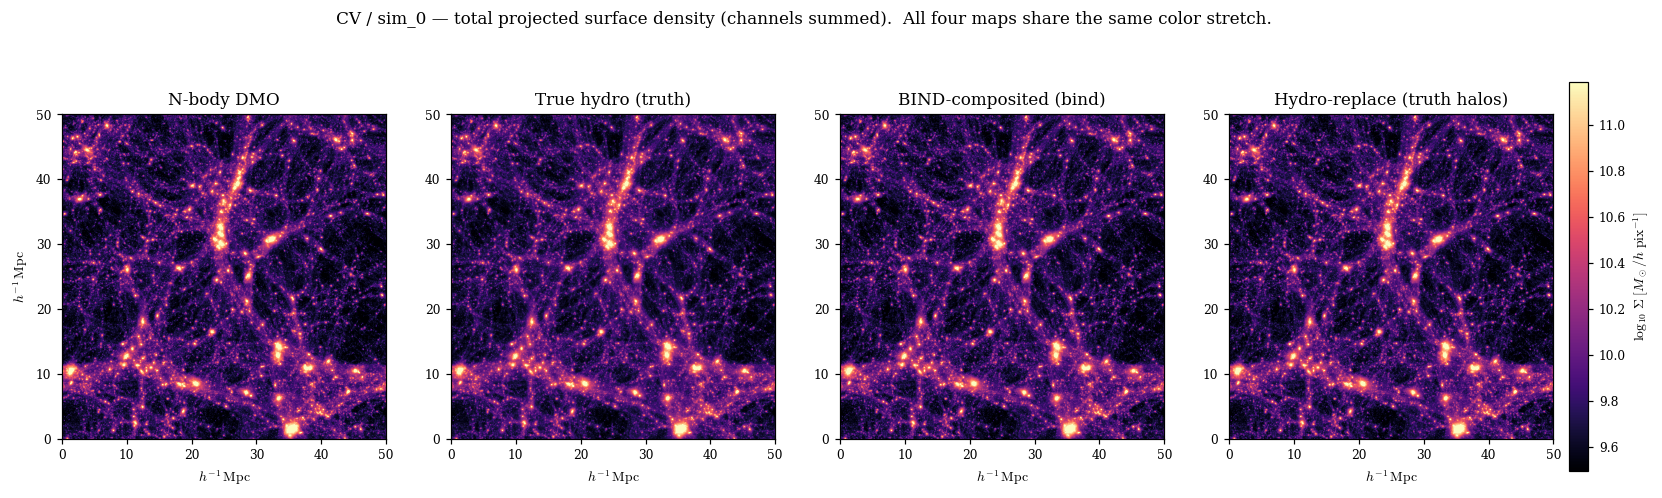

N-body DMO                        sum = 1.041e+16,  mean = 9.926e+09
True hydro (truth)                sum = 1.041e+16,  mean = 9.926e+09
BIND-composited (bind)            sum = 1.041e+16,  mean = 9.926e+09
Hydro-replace (truth halos)       sum = 1.037e+16,  mean = 9.894e+09


In [80]:
# ── Visual anchor: one CV sim, four maps side-by-side ────────────────────────
# DMO, truth, BIND-composited, hydro_replace at the same log10 surface-density
# stretch.  This is the figure that anchors what every later P(k) plot is
# measuring.
ANCHOR_SIM = 'sim_0'    # any CV sim works; sim_0 has a nice massive cluster

truth_a, gen_a, hyd_a, dmo_a, ok = load_maps('CV', ANCHOR_SIM)
assert ok, f'CV/{ANCHOR_SIM} maps not found'

# Use a common log stretch driven by the truth map (avoids divide-by-zero on
# DMO pixels in voids).
eps = max(1.0, np.percentile(truth_a, 1))
log_truth = np.log10(truth_a + eps)
vmin, vmax = np.percentile(log_truth, [1, 99.5])

panels = [
    ('N-body DMO',                   dmo_a),
    ('True hydro (truth)',           truth_a),
    ('BIND-composited (bind)',       gen_a),
    ('Hydro-replace (truth halos)',  hyd_a),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, (title, m) in zip(axes, panels):
    im = ax.imshow(np.log10(m + eps), origin='lower', cmap='magma',
                   vmin=vmin, vmax=vmax,
                   extent=[0, BOX_SIZE_MPH, 0, BOX_SIZE_MPH])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r'$h^{-1}\,\rm Mpc$', fontsize=9)
    ax.tick_params(labelsize=8)
axes[0].set_ylabel(r'$h^{-1}\,\rm Mpc$', fontsize=9)

cbar = fig.colorbar(im, ax=axes, fraction=0.018, pad=0.01)
cbar.set_label(r'$\log_{10}\,\Sigma\;[M_\odot/h\;{\rm pix}^{-1}]$', fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(f'CV / {ANCHOR_SIM} — total projected surface density '
             '(channels summed).  All four maps share the same color stretch.',
             fontsize=11, y=1.02)
plt.show()

# Quick sanity: the four maps should have similar total mass (they are derived
# from the same N-body field plus painted/true halos).
for title, m in panels:
    print(f'{title:32s}  sum = {m.sum():.3e},  mean = {m.mean():.3e}')

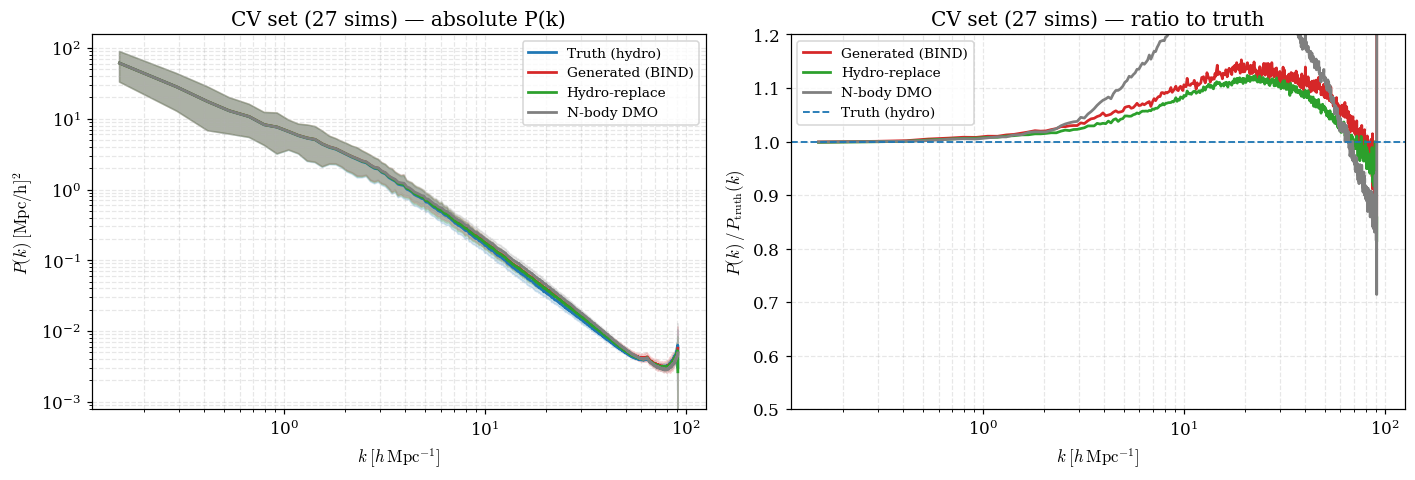

In [81]:
def plot_cv_ps(k, pk_truth, pk_gen, pk_hydrep, pk_dmo, title='CV set'):
    """Plot mean ± 1σ power spectra for truth, generated, hydro-replace, dmo."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    colors = {'truth': '#1f77b4', 'gen': '#d62728', 'hydro_rep': '#2ca02c', 'dmo': '#7f7f7f'}
    labels = {'truth': 'Truth (hydro)', 'gen': 'Generated (BIND)', 'hydro_rep': 'Hydro-replace', 'dmo': 'N-body DMO'}

    def _band(ax, k, pks, color, label):
        mean = pks.mean(0)
        std  = pks.std(0)
        ax.loglog(k, mean, color=color, label=label, lw=1.8)
        ax.fill_between(k, mean - std, mean + std, color=color, alpha=0.18)

    # Left: absolute P(k)
    ax = axes[0]
    _band(ax, k, pk_truth,  colors['truth'],     labels['truth'])
    _band(ax, k, pk_gen,    colors['gen'],        labels['gen'])
    _band(ax, k, pk_hydrep, colors['hydro_rep'],  labels['hydro_rep'])
    _band(ax, k, pk_dmo,    colors['dmo'],        labels['dmo'])
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k)\;[\mathrm{Mpc/h}]^2$')
    ax.set_title(f'{title} — absolute P(k)')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', ls='--', alpha=0.3)

    # Right: ratio P(k) / P_truth(k)
    ax = axes[1]
    mean_truth = pk_truth.mean(0)
    for pks, color, label in [
        (pk_gen,    colors['gen'],       labels['gen']),
        (pk_hydrep, colors['hydro_rep'], labels['hydro_rep']),
        (pk_dmo,    colors['dmo'],       labels['dmo']),
    ]:
        mean_r = pks.mean(0) / mean_truth
        ax.semilogx(k, mean_r, color=color, label=label, lw=1.8)
    ax.axhline(1, color=colors['truth'], ls='--', lw=1.2, label=labels['truth'])
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k)\,/\,P_{\rm truth}(k)$')
    ax.set_title(f'{title} — ratio to truth')
    ax.legend(fontsize=9)
    ax.set_ylim(0.5, 1.2)
    ax.grid(True, which='both', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


fig_cv = plot_cv_ps(k_cv, pk_truth_cv, pk_gen_cv, pk_hyd_cv, pk_dmo_cv, title='CV set (27 sims)')

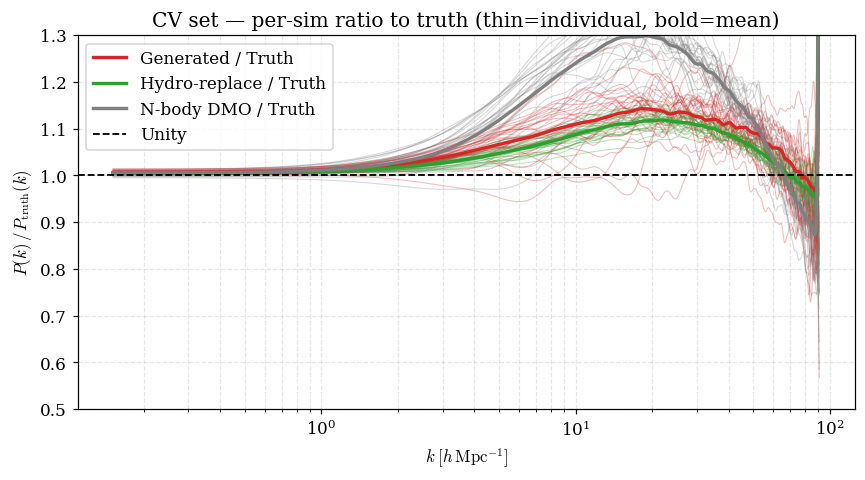

In [82]:
# CV: per-sim ratio curves (individual lines, thin + mean on top)
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, sid in enumerate(sims_cv):
    ratio_gen = pk_gen_cv[i]    / pk_truth_cv[i]
    ratio_hyd = pk_hyd_cv[i]    / pk_truth_cv[i]
    ratio_dmo = pk_dmo_cv[i]    / pk_truth_cv[i]
    ax.semilogx(k_cv, smooth_pk(ratio_gen), color='#d62728', alpha=0.3, lw=0.7)
    ax.semilogx(k_cv, smooth_pk(ratio_hyd), color='#2ca02c', alpha=0.3, lw=0.7)
    ax.semilogx(k_cv, smooth_pk(ratio_dmo), color='#7f7f7f', alpha=0.3, lw=0.7)

# Bold mean lines
ax.semilogx(k_cv, smooth_pk((pk_gen_cv / pk_truth_cv).mean(0)), color='#d62728', lw=2.2, label='Generated / Truth')
ax.semilogx(k_cv, smooth_pk((pk_hyd_cv / pk_truth_cv).mean(0)), color='#2ca02c', lw=2.2, label='Hydro-replace / Truth')
ax.semilogx(k_cv, smooth_pk((pk_dmo_cv / pk_truth_cv).mean(0)), color='#7f7f7f', lw=2.2, label='N-body DMO / Truth')
ax.axhline(1, ls='--', color='k', lw=1.2, label='Unity')
ax.set_ylim(0.5, 1.3)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\,/\,P_{\rm truth}(k)$')
ax.set_title('CV set — per-sim ratio to truth (thin=individual, bold=mean)')
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Pinning the residual: BIND vs hydro-replace

We now isolate the *BIND-attributable* error.  Two ratios make this explicit:

- $P_{\rm BIND}/P_{\rm truth}$ and $P_{\rm hydro\_replace}/P_{\rm truth}$ — the **same shape** at the level the eye can resolve means BIND is doing what halo-pasting at this mass floor *should* do.  The gap from unity in both is the *mass-floor deficit*.
- $P_{\rm BIND}/P_{\rm hydro\_replace}$ — this directly measures the BIND error, with the sub-threshold-halo contribution divided out by construction.

We overlay the characteristic wavenumber of the mass-threshold halos,
$$
k_{R_{200c}}(M_{\rm thr}) \;=\; \frac{2\pi}{R_{200c}(M_{\rm thr})}, \qquad
R_{200c} = \left(\frac{3\,M_{\rm thr}}{4\pi\,200\,\rho_{\rm crit}}\right)^{1/3},
$$
with $\rho_{\rm crit}\!=\!2.775\times 10^{11}\,M_\odot\,h^{-1}/({\rm Mpc}/h)^3$ at $z\!=\!0$.  Halos *below* the mass floor have $R_{200c}\!<\!R_{200c}(M_{\rm thr})$, so their missing baryonic redistribution shows up at $k\!\gtrsim\! k_{R_{200c}}(M_{\rm thr})$.

M_thr = 1.0e+13 M_sun/h  ⇒  R200 = 0.350 Mpc/h,  k_R200 = 17.93 h/Mpc


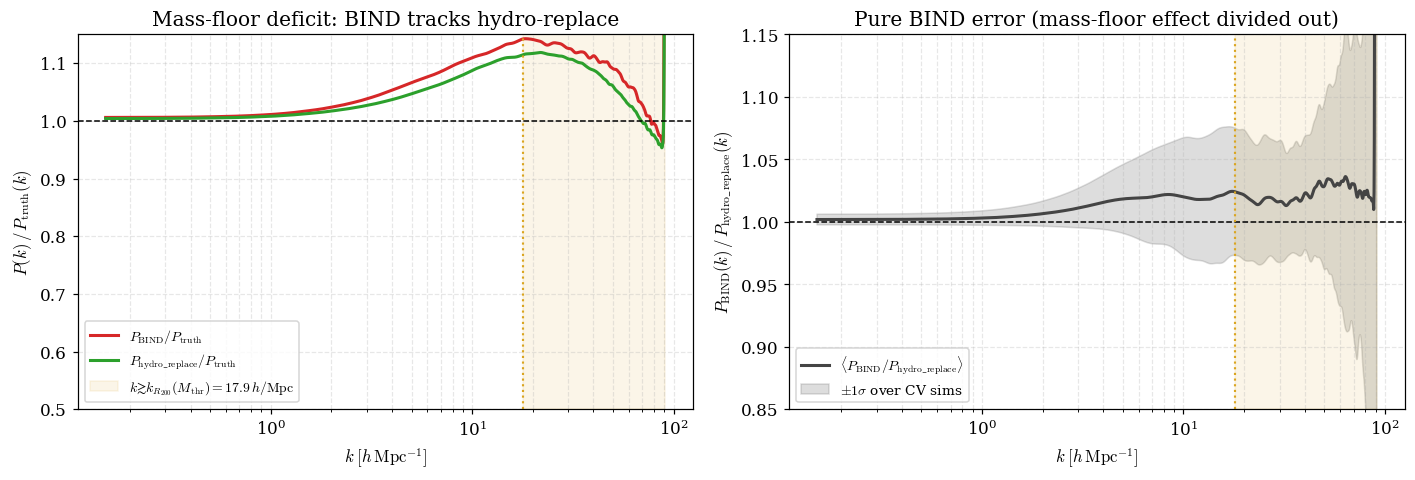

|BIND/hydro_replace - 1|  median, k <  k_thr: 1.878%
|BIND/hydro_replace - 1|  median, k >= k_thr: 2.440%


In [83]:
# ── k_R200(M_thr) for the mass-threshold marker ──────────────────────────────
RHO_CRIT_Z0   = 2.775e11   # M_sun/h per (Mpc/h)^3 at z=0
MASS_THRESHOLD = 1.0e13    # M_sun/h, matches MODEL_SUBDIR

def k_R200(M, rho_crit=RHO_CRIT_Z0):
    """Characteristic wavenumber 2π/R_200c for a halo of mass M [M_sun/h]."""
    R200 = (3.0 * M / (4 * np.pi * 200 * rho_crit)) ** (1.0/3.0)
    return 2 * np.pi / R200, R200

k_thr, R200_thr = k_R200(MASS_THRESHOLD)
print(f'M_thr = {MASS_THRESHOLD:.1e} M_sun/h  ⇒  '
      f'R200 = {R200_thr:.3f} Mpc/h,  k_R200 = {k_thr:.2f} h/Mpc')

# Mean ratios over CV sims
mean_bind  = (pk_gen_cv / pk_truth_cv).mean(0)
mean_hyrep = (pk_hyd_cv / pk_truth_cv).mean(0)
mean_bbyhyrep = (pk_gen_cv / pk_hyd_cv).mean(0)
std_bbyhyrep  = (pk_gen_cv / pk_hyd_cv).std(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

# Left: BIND/truth vs hydro_replace/truth — should overlay
ax = axes[0]
ax.semilogx(k_cv, smooth_pk(mean_bind),  color='#d62728', lw=2.0, label=r'$P_{\rm BIND}/P_{\rm truth}$')
ax.semilogx(k_cv, smooth_pk(mean_hyrep), color='#2ca02c', lw=2.0, label=r'$P_{\rm hydro\_replace}/P_{\rm truth}$')
ax.axhline(1.0, color='k', ls='--', lw=1.0)
ax.axvspan(k_thr, k_cv.max(), color='goldenrod', alpha=0.10,
           label=fr'$k \gtrsim k_{{R_{{200}}}}(M_{{\rm thr}})={k_thr:.1f}\,h/{{\rm Mpc}}$')
ax.axvline(k_thr, color='goldenrod', ls=':', lw=1.4)
ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\,/\,P_{\rm truth}(k)$')
ax.set_ylim(0.5, 1.15)
ax.set_title('Mass-floor deficit: BIND tracks hydro-replace')
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', ls='--', alpha=0.3)

# Right: BIND/hydro_replace — the pure BIND error
ax = axes[1]
ax.semilogx(k_cv, smooth_pk(mean_bbyhyrep), color='#444444', lw=2.0,
            label=r'$\langle P_{\rm BIND}/P_{\rm hydro\_replace}\rangle$')
ax.fill_between(k_cv,
                smooth_pk(mean_bbyhyrep - std_bbyhyrep),
                smooth_pk(mean_bbyhyrep + std_bbyhyrep),
                color='#444444', alpha=0.18, label=r'$\pm 1\sigma$ over CV sims')
ax.axhline(1.0, color='k', ls='--', lw=1.0)
ax.axvspan(k_thr, k_cv.max(), color='goldenrod', alpha=0.10)
ax.axvline(k_thr, color='goldenrod', ls=':', lw=1.4)
ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\rm BIND}(k)\,/\,P_{\rm hydro\_replace}(k)$')
ax.set_ylim(0.85, 1.15)
ax.set_title('Pure BIND error (mass-floor effect divided out)')
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical summary: median |BIND/hydro_replace - 1| at low and high k
mask_low  = k_cv < k_thr
mask_high = k_cv >= k_thr
med_low  = np.median(np.abs(mean_bbyhyrep[mask_low]  - 1))
med_high = np.median(np.abs(mean_bbyhyrep[mask_high] - 1))
print(f'|BIND/hydro_replace - 1|  median, k <  k_thr: {med_low:.3%}')
print(f'|BIND/hydro_replace - 1|  median, k >= k_thr: {med_high:.3%}')

### Cross-correlation $r(k)$ — mode-by-mode agreement

$P(k)$ tests *amplitude*; it does not distinguish a generated field that lives on the *same modes* as the truth from one that has the right power but the wrong phases.  Define
$$
r_{XY}(k) \;=\; \frac{P_{XY}(k)}{\sqrt{P_{XX}(k)\,P_{YY}(k)}},
$$
the cross-correlation coefficient.  $r\!=\!1$ means the two fields are mode-identical at wavenumber $k$; $r\!=\!0$ means uncorrelated; negative $r$ means anti-correlated.

Two comparisons of interest:

- $r_{\rm BIND,truth}(k)$ — does BIND-generated mass sit on the same Fourier modes as the true hydro field?
- $r_{\rm hydro\_replace,truth}(k)$ — what's the ceiling at this mass floor (true halos *can* differ from the full hydro at scales dominated by sub-threshold halos, so this is not identically 1 either).

For context, $r_{\rm DMO,truth}(k)$ is the cross-correlation between the unbaryonified N-body and the true hydro — the *baseline*.  Sharma et al. (2024) build their transfer-function approach on the empirical fact that this baseline stays close to 1 down to small scales; we should see BIND raise it further on scales where the painted halos live.

In [84]:
# ── Cross-correlation r(k) for one pair of 2D maps ───────────────────────────
def cross_pk_2d(a, b, box_size, n_kbins=None):
    """Bin-averaged auto- and cross-power for two 2D maps + r(k).

    Parameters
    ----------
    a, b : (H, W) maps (positive, surface-density-like; normalized internally)
    box_size : float, side length in Mpc/h
    n_kbins  : number of linear k-bins.  Default uses fundamental-mode spacing.

    Returns
    -------
    k       : (Nk,) bin centers in h/Mpc
    p_aa, p_bb, p_ab : auto- and cross-spectra (binned mean over k-shells)
    r       : (Nk,) cross-correlation coefficient
    nmodes  : (Nk,) number of Fourier modes per bin (>0)
    """
    H, W = a.shape
    assert b.shape == a.shape
    L  = box_size
    kf = 2 * np.pi / L                          # fundamental mode

    da = a.astype(np.float64) / a.mean() - 1.0
    db = b.astype(np.float64) / b.mean() - 1.0
    fa = np.fft.fft2(da)
    fb = np.fft.fft2(db)

    # 2D wavenumber grid
    kx = np.fft.fftfreq(W, d=L / W) * 2 * np.pi
    ky = np.fft.fftfreq(H, d=L / H) * 2 * np.pi
    K  = np.sqrt(kx[None, :]**2 + ky[:, None]**2)

    # Pylians Pk_plane normalization: P = |delta_k|^2 * L^2 / (H*W)^2
    norm  = L * L / (H * W) ** 2
    p_ab_pix = (fa.conj() * fb).real * norm
    p_aa_pix = (fa.conj() * fa).real * norm
    p_bb_pix = (fb.conj() * fb).real * norm

    if n_kbins is None:
        n_kbins = int(np.floor(K.max() / kf))
    edges   = np.arange(n_kbins + 1) * kf
    centers = 0.5 * (edges[:-1] + edges[1:])

    flatK = K.ravel()
    idx   = np.clip((flatK / kf).astype(int), 0, n_kbins - 1)

    nmodes = np.bincount(idx, minlength=n_kbins).astype(np.float64)
    p_aa   = np.bincount(idx, weights=p_aa_pix.ravel(), minlength=n_kbins)
    p_bb   = np.bincount(idx, weights=p_bb_pix.ravel(), minlength=n_kbins)
    p_ab   = np.bincount(idx, weights=p_ab_pix.ravel(), minlength=n_kbins)

    keep = nmodes > 0
    p_aa[keep] /= nmodes[keep]
    p_bb[keep] /= nmodes[keep]
    p_ab[keep] /= nmodes[keep]

    denom = np.sqrt(np.maximum(p_aa * p_bb, 1e-300))
    r = p_ab / denom

    return centers[keep], p_aa[keep], p_bb[keep], p_ab[keep], r[keep], nmodes[keep]


# Quick sanity check on the anchor sim
k_x, _, _, _, r_bb, n_modes = cross_pk_2d(truth_a, truth_a, BOX_SIZE_MPH)
assert np.allclose(r_bb, 1.0, atol=1e-6), 'r(truth,truth) should be 1'
print(f'Sanity: cross_pk_2d returns {len(k_x)} k-bins, r(truth,truth) ≈ 1.')

Sanity: cross_pk_2d returns 724 k-bins, r(truth,truth) ≈ 1.


  r(k) done 1/27  (sim_0)
  r(k) done 2/27  (sim_1)
  r(k) done 3/27  (sim_10)
  r(k) done 4/27  (sim_11)
  r(k) done 5/27  (sim_12)
  r(k) done 6/27  (sim_13)
  r(k) done 7/27  (sim_14)
  r(k) done 8/27  (sim_15)
  r(k) done 9/27  (sim_16)
  r(k) done 10/27  (sim_17)
  r(k) done 11/27  (sim_18)
  r(k) done 12/27  (sim_19)
  r(k) done 13/27  (sim_2)
  r(k) done 14/27  (sim_20)
  r(k) done 15/27  (sim_21)
  r(k) done 16/27  (sim_22)
  r(k) done 17/27  (sim_23)
  r(k) done 18/27  (sim_24)
  r(k) done 19/27  (sim_25)
  r(k) done 20/27  (sim_26)
  r(k) done 21/27  (sim_3)
  r(k) done 22/27  (sim_4)
  r(k) done 23/27  (sim_5)
  r(k) done 24/27  (sim_6)
  r(k) done 25/27  (sim_7)
  r(k) done 26/27  (sim_8)
  r(k) done 27/27  (sim_9)
r(k) cache saved → analysis_physics_cache/fullmap_cross_correlation_cv.npz
r(k) computed for 27 CV sims; 724 k-bins.


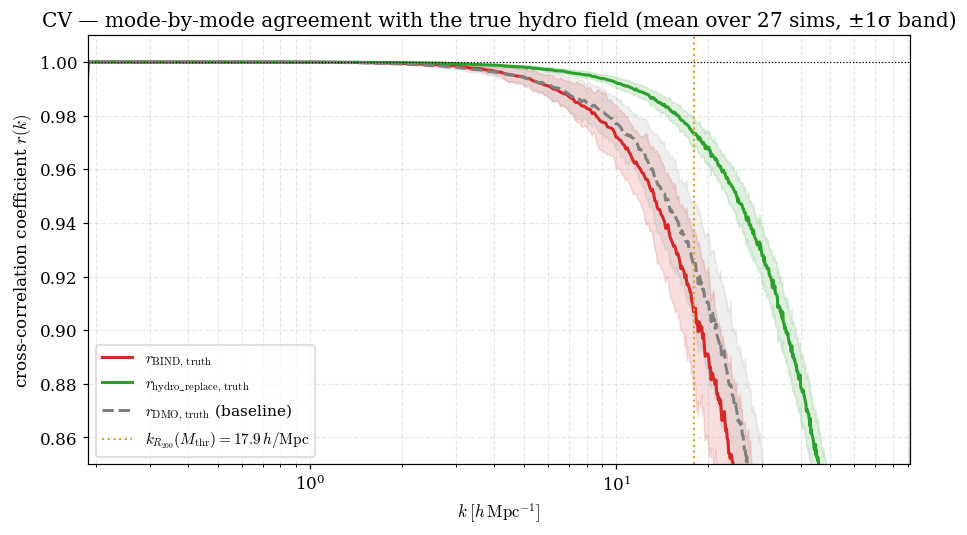

In [85]:
# ── CV: compute r(k) for BIND, hydro_replace, DMO vs truth ───────────────────
# Cached to disk because it requires loading the full 1024x1024 maps for every CV sim.
RK_CACHE = CACHE_DIR / 'fullmap_cross_correlation_cv.npz'

def build_rk_cv(regenerate=False):
    if RK_CACHE.exists() and not regenerate:
        d = np.load(RK_CACHE)
        return d['k'], d['r_bind'], d['r_hyrep'], d['r_dmo'], list(d['sims'])
    rs_bind, rs_hyrep, rs_dmo, sims_kept = [], [], [], []
    k_ref = None
    for n, sid in enumerate(sims_cv):
        truth, gen, hyd, dmo, ok = load_maps('CV', sid)
        if not ok:
            print(f'  ⚠ missing CV/{sid}'); continue
        k, _, _, _, r_b, _ = cross_pk_2d(gen,   truth, BOX_SIZE_MPH)
        _, _, _, _, r_h, _ = cross_pk_2d(hyd,   truth, BOX_SIZE_MPH)
        _, _, _, _, r_d, _ = cross_pk_2d(dmo,   truth, BOX_SIZE_MPH)
        if k_ref is None:
            k_ref = k
        rs_bind.append(r_b); rs_hyrep.append(r_h); rs_dmo.append(r_d)
        sims_kept.append(sid)
        print(f'  r(k) done {n+1}/{len(sims_cv)}  ({sid})')
    rs_bind  = np.stack(rs_bind)
    rs_hyrep = np.stack(rs_hyrep)
    rs_dmo   = np.stack(rs_dmo)
    np.savez(RK_CACHE, k=k_ref, r_bind=rs_bind, r_hyrep=rs_hyrep,
             r_dmo=rs_dmo, sims=np.array(sims_kept))
    print(f'r(k) cache saved → {RK_CACHE}')
    return k_ref, rs_bind, rs_hyrep, rs_dmo, sims_kept


k_rk, r_bind_cv, r_hyrep_cv, r_dmo_cv, sims_rk = build_rk_cv(regenerate=False)
print(f'r(k) computed for {len(sims_rk)} CV sims; {len(k_rk)} k-bins.')

# Plot
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.semilogx(k_rk, r_bind_cv.mean(0),  color='#d62728', lw=2.0, label=r'$r_{\rm BIND,\,truth}$')
ax.fill_between(k_rk, r_bind_cv.mean(0)  - r_bind_cv.std(0),
                       r_bind_cv.mean(0)  + r_bind_cv.std(0),  color='#d62728', alpha=0.15)
ax.semilogx(k_rk, r_hyrep_cv.mean(0), color='#2ca02c', lw=2.0, label=r'$r_{\rm hydro\_replace,\,truth}$')
ax.fill_between(k_rk, r_hyrep_cv.mean(0) - r_hyrep_cv.std(0),
                       r_hyrep_cv.mean(0) + r_hyrep_cv.std(0), color='#2ca02c', alpha=0.15)
ax.semilogx(k_rk, r_dmo_cv.mean(0),   color='#7f7f7f', lw=2.0, ls='--', label=r'$r_{\rm DMO,\,truth}$ (baseline)')
ax.fill_between(k_rk, r_dmo_cv.mean(0)   - r_dmo_cv.std(0),
                       r_dmo_cv.mean(0)   + r_dmo_cv.std(0),   color='#7f7f7f', alpha=0.12)
ax.axhline(1.0, color='k', ls=':', lw=0.8)
ax.axvline(k_thr, color='goldenrod', ls=':', lw=1.4,
           label=fr'$k_{{R_{{200}}}}(M_{{\rm thr}})={k_thr:.1f}\,h/{{\rm Mpc}}$')

ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'cross-correlation coefficient $r(k)$')
ax.set_ylim(0.85, 1.01)
ax.set_xlim(k_rk[1], k_rk[-1])
ax.set_title('CV — mode-by-mode agreement with the true hydro field (mean over 27 sims, ±1σ band)')
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Why is $r_{\rm BIND,truth} < r_{\rm DMO,truth}$?

This looks paradoxical at first — BIND clearly produces a *better* $P(k)$ than DMO, so it should also have a higher cross-correlation, right? It does not, for a subtle reason that has nothing to do with BIND being wrong:

1. **The DMO field is already very close to truth outside halos.** Hydro and DMO are evolved from identical ICs with the same gravity solver; baryons only meaningfully redistribute mass *inside* halos. So $r_{\rm DMO,truth}$ starts very close to 1 essentially for free — it is dominated by the large fraction of the box volume where hydro $\approx$ DMO by construction.
2. **BIND replaces halo regions with stochastic samples.** Inside halos, BIND draws from the learned conditional $p(\Sigma_{\rm hydro}\mid\Sigma_{\rm DMO},\boldsymbol{\theta})$. The *statistics* of these samples match truth (correct $P(k)$, correct profiles, correct shapes), but the specific Fourier *phases* inside any one halo are sample-dependent, not realization-matched. So BIND injects phase noise inside halos that DMO simply does not have, slightly *lowering* the raw $r(k)$.

The cleaner test is to ask whether BIND's *baryonic correction* tracks truth's *baryonic correction*. Define
$$
\Delta_X \;\equiv\; X - \Sigma_{\rm DMO}, \qquad X \in \{{\rm truth},\,{\rm BIND},\,{\rm hydro\_replace}\},
$$
so $\Delta$ isolates the field that any baryonification method must inject on top of DMO.  Then
$$
r_{\Delta_X,\Delta_{\rm truth}}(k) \;=\; \frac{P_{\Delta_X \Delta_{\rm truth}}(k)}{\sqrt{P_{\Delta_X}(k)\,P_{\Delta_{\rm truth}}(k)}}
$$
directly measures whether the painted baryonic correction lives on the same modes as the true one — the DMO baseline drops out by construction.  In this metric there is no "DMO baseline" to beat, because $\Delta_{\rm DMO}\equiv 0$ by definition.

In [ ]:
# ── r(Δ_X, Δ_truth): cross-correlation of baryonic perturbations ----------
# Compute on the fly for each CV sim. The "perturbation" field is the
# difference between each map and the DMO baseline; we then re-use cross_pk_2d.
# Note: cross_pk_2d internally normalizes by the field mean. Δ fields have mean
# near zero, so we add a strictly positive offset before normalization. r(k)
# is invariant under this constant offset because it cancels in numerator and
# denominator.

DELTA_RK_CACHE = CACHE_DIR / 'fullmap_delta_cross_correlation_cv.npz'

def _safe_offset(field):
    # Choose an offset that makes the field strictly positive while preserving
    # all spatial structure.  Pylians normalization (used inside cross_pk_2d)
    # then sees a positive mean.
    return float(np.abs(field).max()) + 1.0

def build_delta_rk_cv(regenerate=False):
    if DELTA_RK_CACHE.exists() and not regenerate:
        d = np.load(DELTA_RK_CACHE)
        return d['k'], d['r_bind'], d['r_hyrep'], list(d['sims'])
    rs_bind, rs_hyrep, sims_kept = [], [], []
    k_ref = None
    for n, sid in enumerate(sims_cv):
        truth, gen, hyd, dmo, ok = load_maps('CV', sid)
        if not ok:
            print(f'  ⚠ missing CV/{sid}'); continue
        d_truth = truth - dmo
        d_bind  = gen   - dmo
        d_hyrep = hyd   - dmo
        off = _safe_offset(np.concatenate([d_truth.ravel(), d_bind.ravel(), d_hyrep.ravel()]))
        k, _, _, _, r_b, _ = cross_pk_2d(d_bind  + off, d_truth + off, BOX_SIZE_MPH)
        _, _, _, _, r_h, _ = cross_pk_2d(d_hyrep + off, d_truth + off, BOX_SIZE_MPH)
        if k_ref is None:
            k_ref = k
        rs_bind.append(r_b); rs_hyrep.append(r_h); sims_kept.append(sid)
        print(f'  Δ r(k) done {n+1}/{len(sims_cv)}  ({sid})')
    rs_bind  = np.stack(rs_bind)
    rs_hyrep = np.stack(rs_hyrep)
    np.savez(DELTA_RK_CACHE, k=k_ref, r_bind=rs_bind, r_hyrep=rs_hyrep,
             sims=np.array(sims_kept))
    print(f'Δ r(k) cache saved → {DELTA_RK_CACHE}')
    return k_ref, rs_bind, rs_hyrep, sims_kept


k_drk, r_dbind_cv, r_dhyrep_cv, sims_drk = build_delta_rk_cv(regenerate=False)
print(f'Δ r(k) computed for {len(sims_drk)} CV sims; {len(k_drk)} k-bins.')

# Plot
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.semilogx(k_drk, r_dbind_cv.mean(0),  color='#d62728', lw=2.0,
            label=r'$r_{\Delta_{\rm BIND},\,\Delta_{\rm truth}}$')
ax.fill_between(k_drk, r_dbind_cv.mean(0)  - r_dbind_cv.std(0),
                        r_dbind_cv.mean(0)  + r_dbind_cv.std(0),  color='#d62728', alpha=0.15)
ax.semilogx(k_drk, r_dhyrep_cv.mean(0), color='#2ca02c', lw=2.0,
            label=r'$r_{\Delta_{\rm hydro\_replace},\,\Delta_{\rm truth}}$ — ceiling')
ax.fill_between(k_drk, r_dhyrep_cv.mean(0) - r_dhyrep_cv.std(0),
                        r_dhyrep_cv.mean(0) + r_dhyrep_cv.std(0), color='#2ca02c', alpha=0.15)
ax.axhline(1.0, color='k', ls=':', lw=0.8)
ax.axhline(0.0, color='k', ls='-', lw=0.6)
ax.axvspan(k_thr, k_drk.max(), color='goldenrod', alpha=0.10)
ax.axvline(k_thr, color='goldenrod', ls=':', lw=1.4,
           label=fr'$k_{{R_{{200}}}}(M_{{\rm thr}})={k_thr:.1f}\,h/{{\rm Mpc}}$')

ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$r(\Delta_X,\,\Delta_{\rm truth})$')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(k_drk[1], k_drk[-1])
ax.set_title('CV — mode-alignment of the baryonic correction (Δ = X − DMO)')
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 1P suite — parameter sensitivity

Each 1P sim varies one of the 35 SB35 parameters away from the fiducial, keeping the others fixed. We can therefore ask: *does BIND reproduce the correct P(k) response to each parameter?*

We load parameters from `run_config` stored in each sim's `summary.json`, or fall back to the manifest.

In [86]:
import re

def parse_1p_sim_id(sim_id: str):
    """Parse a 1P sim_id into (param_index, level_str).

    Returns
    -------
    param_idx : int (1-based) or None if not a 1P sim
    level     : str e.g. '0', '1', '2', 'n1', 'n2'
    """
    m = re.match(r'^1P_p(\d+)_(.+)$', sim_id)
    if m is None:
        return None, None
    return int(m.group(1)), m.group(2)


def level_to_sign(level: str) -> float:
    """Map level string to a numeric value for sorting/plotting.
    n2 -> -2, n1 -> -1, 0 -> 0, 1 -> +1, 2 -> +2, etc.
    """
    if level.startswith('n'):
        return -float(level[1:])
    return float(level)


# Load 1P suite
k_1p, pk_truth_1p, pk_gen_1p, pk_hyd_1p, pk_dmo_1p, sims_1p = extract_suite_ps(catalog, '1P')
print(f'1P sims: {len(sims_1p)},  k shape: {k_1p.shape}')

# Parse sim_ids into (param_idx, level) and sort
parsed = [parse_1p_sim_id(s) for s in sims_1p]
print('Sample parsed:', list(zip(sims_1p[:6], parsed[:6])))

1P sims: 139,  k shape: (724,)
Sample parsed: [('1P_p10_1', (10, '1')), ('1P_p10_2', (10, '2')), ('1P_p10_n1', (10, 'n1')), ('1P_p10_n2', (10, 'n2')), ('1P_p11_1', (11, '1')), ('1P_p11_2', (11, '2'))]


In [87]:
def get_1p_fiducial_pk(k_1p, pk_truth_1p, pk_gen_1p, pk_hyd_1p, sims_1p):
    """Return the fiducial (1P_p1_0) PS arrays."""
    fid_idx = sims_1p.index('1P_p1_0') if '1P_p1_0' in sims_1p else None
    if fid_idx is None:
        raise RuntimeError("Fiducial sim '1P_p1_0' not found in catalog")
    return pk_truth_1p[fid_idx], pk_gen_1p[fid_idx], pk_hyd_1p[fid_idx]


def compute_1p_response(k, pk_truth, pk_gen, pk_hyd, sim_ids):
    """Compute Pk response relative to fiducial for all 1P sims.

    Returns
    -------
    results : dict keyed by param_idx (1-based), each value is a dict
              with keys 'levels', 'truth_ratio', 'gen_ratio', 'hyd_ratio'
              where each is (N_levels, Nk).
    fid_truth, fid_gen, fid_hyd : fiducial PS arrays (Nk,)
    """
    fid_truth, fid_gen, fid_hyd = get_1p_fiducial_pk(k, pk_truth, pk_gen, pk_hyd, sim_ids)

    # Group by param_idx
    results = {}
    for i, sid in enumerate(sim_ids):
        pidx, level = parse_1p_sim_id(sid)
        if pidx is None:
            continue
        if pidx not in results:
            results[pidx] = {'levels': [], 'truth_ratio': [], 'gen_ratio': [], 'hyd_ratio': []}
        results[pidx]['levels'].append(level_to_sign(level))
        results[pidx]['truth_ratio'].append(pk_truth[i] / fid_truth)
        results[pidx]['gen_ratio'].append(pk_gen[i]   / fid_gen)
        results[pidx]['hyd_ratio'].append(pk_hyd[i]   / fid_hyd)

    # Sort by level within each param
    for pidx in results:
        order = np.argsort(results[pidx]['levels'])
        for key in ('levels', 'truth_ratio', 'gen_ratio', 'hyd_ratio'):
            results[pidx][key] = np.array(results[pidx][key])[order]

    return results, fid_truth, fid_gen, fid_hyd


resp_1p, fid_truth_ps, fid_gen_ps, fid_hyd_ps = compute_1p_response(
    k_1p, pk_truth_1p, pk_gen_1p, pk_hyd_1p, sims_1p)
print(f'Responses computed for {len(resp_1p)} parameters')

Responses computed for 35 parameters


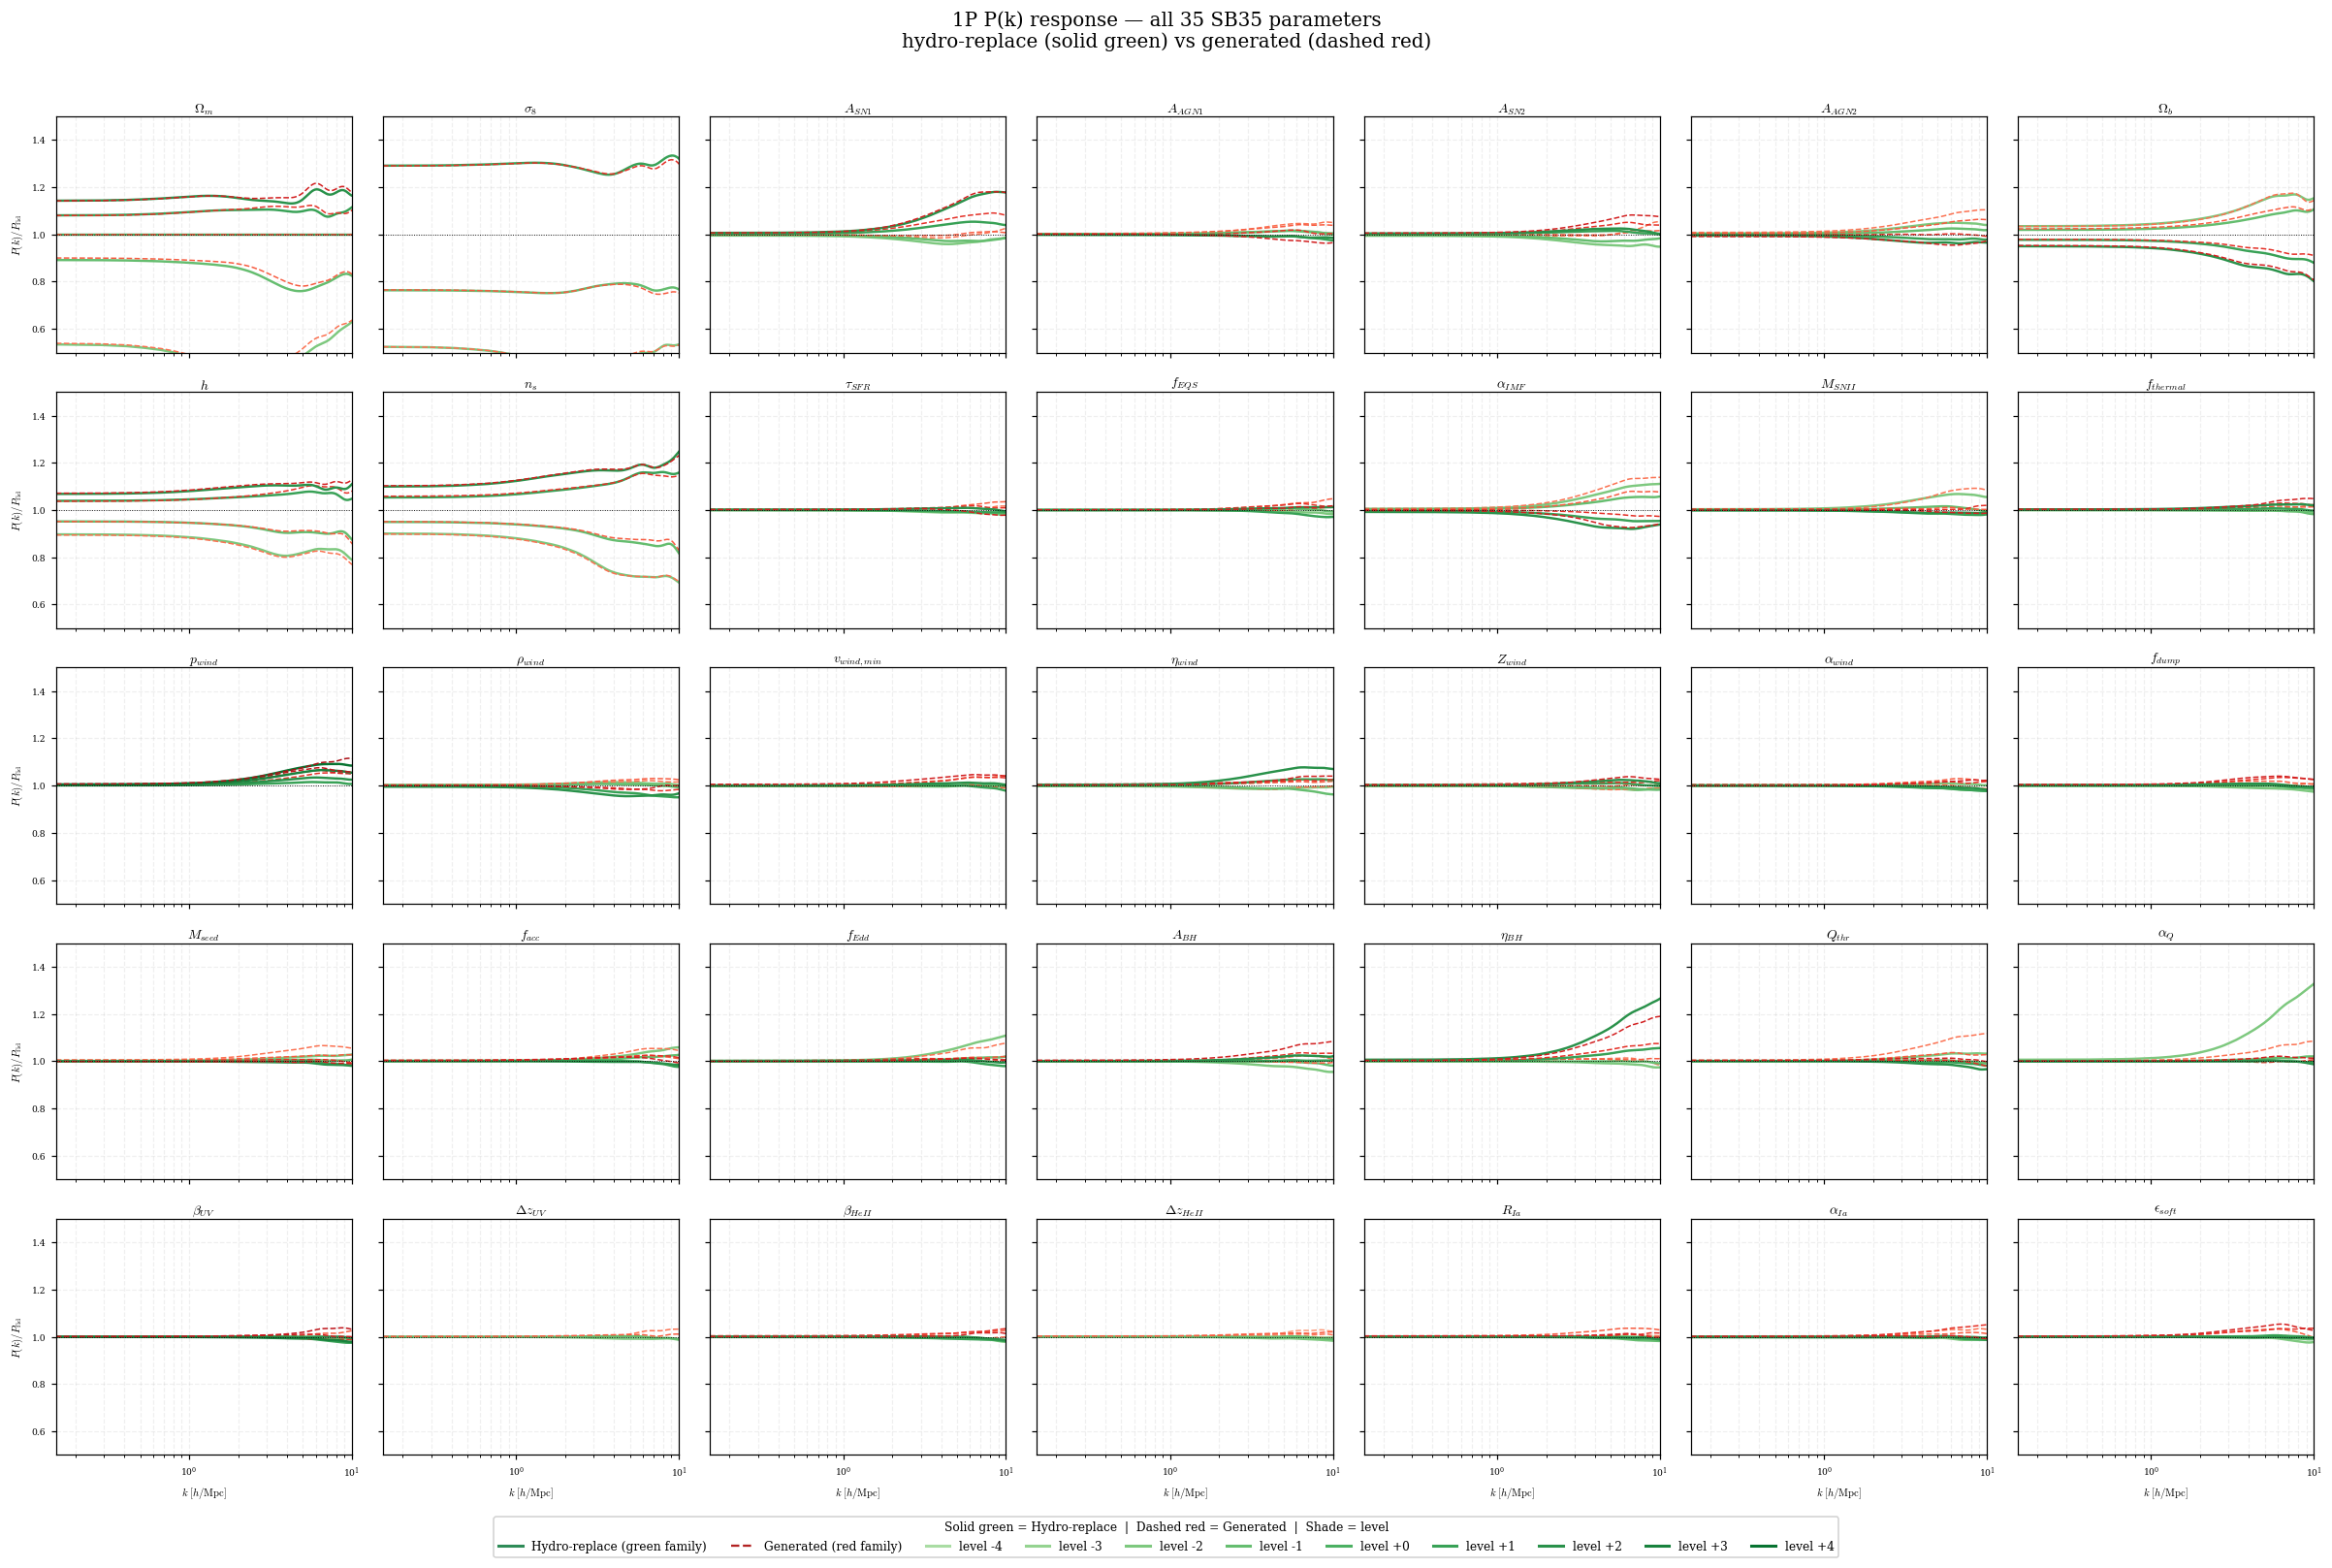

In [88]:
# ── 1P validation: P(k) response for all 35 SB35 parameters ──────────────────
# Green family = hydro-replace  (shade encodes level)
# Red family   = generated BIND (same shade convention)
ALL_PARAMS = sorted(resp_1p.keys())   # should be 1..35

NCOLS, NROWS = 7, 5
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(22, 14),
                         sharex=True, sharey=True)
axes = axes.ravel()

hyd_cmap = plt.cm.Greens
gen_cmap = plt.cm.Reds

# Collect all levels that appear across any param (for a unified legend)
all_levels = sorted({lv for pidx in ALL_PARAMS for lv in resp_1p[pidx]['levels']})
n_lev_all  = len(all_levels)
shades_all = np.linspace(0.35, 0.85, n_lev_all)
level_to_shade = {lv: shades_all[i] for i, lv in enumerate(all_levels)}

for ax_i, pidx in enumerate(ALL_PARAMS):
    ax = axes[ax_i]
    r  = resp_1p[pidx]
    levels = r['levels']
    shades = [level_to_shade[lv] for lv in levels]

    for li in range(len(levels)):
        s    = shades[li]
        hcol = hyd_cmap(s)
        gcol = gen_cmap(s)
        ax.semilogx(k_1p, smooth_pk(r['hyd_ratio'][li]), color=hcol, lw=1.6, ls='-')
        ax.semilogx(k_1p, smooth_pk(r['gen_ratio'][li]), color=gcol, lw=1.0, ls='--')

    ax.axhline(1, color='k', ls=':', lw=0.6)
    ax.set_title(PARAM_LABELS.get(pidx, f'p{pidx}'), fontsize=9, pad=2)
    ax.grid(True, which='both', ls='--', alpha=0.2)
    ax.set_xlim(k_1p.min(), 10)

# Hide any unused axes
for ax in axes[len(ALL_PARAMS):]:
    ax.set_visible(False)

# Axis labels on edges only
for ax_i, ax in enumerate(axes):
    col = ax_i % NCOLS
    row = ax_i // NCOLS
    if row == NROWS - 1:
        ax.set_xlabel(r'$k\;[h/\mathrm{Mpc}]$', fontsize=7)
    if col == 0:
        ax.set_ylabel(r'$P(k)/P_{\rm fid}$', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_ylim(0.5, 1.5)

# ── Shared legend (level × model family) ─────────────────────────────────────
from matplotlib.lines import Line2D
legend_handles = (
    [Line2D([0],[0], color='seagreen',  lw=2,   ls='-',  label='Hydro-replace (green family)'),
     Line2D([0],[0], color='firebrick', lw=1.5, ls='--', label='Generated (red family)')]
    + [Line2D([0],[0], color=hyd_cmap(level_to_shade[lv]), lw=2, ls='-',
               label=f'level {lv:+.0f}') for lv in all_levels]
)
fig.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.03), ncol=len(legend_handles),
           fontsize=8, framealpha=0.9,
           title='Solid green = Hydro-replace  |  Dashed red = Generated  |  Shade = level',
           title_fontsize=8)

fig.suptitle('1P P(k) response — all 35 SB35 parameters\n'
             'hydro-replace (solid green) vs generated (dashed red)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 1P summary — one number per parameter

The 35-panel figure above is comprehensive but hard to use as a paper figure.  Collapse each panel to a single scalar: for every parameter $p$ and every off-fiducial level $\ell$ define the *parameter response*
$$
\mathcal{R}_X(k\,|\,p,\ell) \;\equiv\; \frac{P_X(k\,|\,p,\ell)}{P_X(k\,|\,p,\ell=0)} - 1, \qquad X \in \{{\rm truth},\,{\rm BIND},\,{\rm hydro\_replace}\}.
$$
(Distinct from the field perturbation $\Delta_X = X - \Sigma_{\rm DMO}$ introduced for the cross-correlation plot above — there we asked whether BIND lives on the same Fourier *modes* as truth, here we ask whether the *parameter-induced change* of $P(k)$ in BIND tracks the same change in truth.)

Pool all $(\ell, k)$ pairs (only $\ell\!\ne\!0$; restrict to $k \le k_{R_{200c}}(M_{\rm thr})$ where halo-paste methods can compete) and compute the Pearson correlation between $\mathcal{R}_{\rm BIND}$ and $\mathcal{R}_{\rm truth}$, and likewise for $\mathcal{R}_{\rm hydro\_replace}$.

The signal varies hugely across parameters: some, like $A_{\rm SN1}$ and $A_{\rm AGN1}$, swing $P(k)$ by tens of percent; many tertiary feedback parameters barely move it at all. The Pearson correlation only makes sense where the truth-response RMS is large enough to be measured; below that the correlation is sample noise. We plot both the correlation *and* the truth-response amplitude per parameter so the reader can tell signal from noise.

In [ ]:
# ── Per-parameter Pearson(BIND response, truth response) on the 1P suite ─────
from scipy.stats import pearsonr

# Restrict k to scales where halo-paste methods can compete with full hydro.
K_MAX_RESPONSE = k_thr     # h/Mpc — above this, sub-threshold halos dominate
k_mask = k_1p <= K_MAX_RESPONSE
print(f'1P response: using k in [{k_1p[k_mask].min():.3f}, {K_MAX_RESPONSE:.2f}] h/Mpc')

ALL_PARAMS = sorted(resp_1p.keys())
r_bind_vs_truth  = np.zeros(len(ALL_PARAMS))
r_hyrep_vs_truth = np.zeros(len(ALL_PARAMS))
truth_signal     = np.zeros(len(ALL_PARAMS))   # RMS of R_truth per parameter

for i, pidx in enumerate(ALL_PARAMS):
    r = resp_1p[pidx]
    nonfid = np.array(r['levels']) != 0
    if not nonfid.any():
        r_bind_vs_truth[i]  = np.nan
        r_hyrep_vs_truth[i] = np.nan
        truth_signal[i]     = 0.0
        continue
    R_truth = (r['truth_ratio'][nonfid][:, k_mask] - 1.0).ravel()
    R_bind  = (r['gen_ratio'  ][nonfid][:, k_mask] - 1.0).ravel()
    R_hyrep = (r['hyd_ratio'  ][nonfid][:, k_mask] - 1.0).ravel()
    truth_signal[i] = float(np.sqrt(np.mean(R_truth ** 2)))
    r_bind_vs_truth[i]  = pearsonr(R_bind,  R_truth).statistic if np.std(R_truth) > 0 else np.nan
    r_hyrep_vs_truth[i] = pearsonr(R_hyrep, R_truth).statistic if np.std(R_truth) > 0 else np.nan

order = np.argsort(-truth_signal)   # parameters by truth-response amplitude

# ── Plot: twin axis encodes Pearson (bars) and truth-response RMS (markers) ──
fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(ALL_PARAMS))
ax.bar(x - 0.18, r_hyrep_vs_truth[order], width=0.36, color='#2ca02c',
       label=r'$\rho(\mathcal{R}_{\rm hydro\_replace},\,\mathcal{R}_{\rm truth})$ — ceiling')
ax.bar(x + 0.18, r_bind_vs_truth[order],  width=0.36, color='#d62728',
       label=r'$\rho(\mathcal{R}_{\rm BIND},\,\mathcal{R}_{\rm truth})$')
ax.axhline(1.0, color='k', ls=':', lw=0.8)
ax.axhline(0.0, color='k', ls='-', lw=0.6)
ax.set_ylim(-0.4, 1.05)
ax.set_ylabel(r'Pearson $\rho$ with truth response (bars)')

xtl = [PARAM_LABELS.get(ALL_PARAMS[j], f'p{ALL_PARAMS[j]}') for j in order]
ax.set_xticks(x)
ax.set_xticklabels(xtl, rotation=60, ha='right', fontsize=8)

ax2 = ax.twinx()
amp_sorted = truth_signal[order]
ax2.plot(x, amp_sorted, marker='D', linestyle='None', color='#1f77b4',
         markersize=6,
         label=r'truth-response RMS  $\sqrt{\langle\mathcal{R}_{\rm truth}^2\rangle}$')
ax2.set_ylabel(r'truth-response RMS (blue markers)', color='#1f77b4')
ax2.tick_params(axis='y', colors='#1f77b4')
ax2.set_ylim(0, max(0.05, 1.10 * amp_sorted.max()))

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, loc='upper right')
ax.grid(axis='y', ls='--', alpha=0.3)
ax.set_title(f'1P parameter response on the full N-body box  '
             f'($k\\le{K_MAX_RESPONSE:.1f}\\,h/$Mpc;  parameters ordered by truth-response RMS)')

plt.tight_layout()
plt.show()

# Numerical summary: top 10 by truth-response amplitude
print('\nTop-10 parameters by truth-response RMS:')
print(f'  {"parameter":>20s}  RMS(R_truth)   rho_BIND     rho_hydro_replace')
for j in order[:10]:
    pidx = ALL_PARAMS[j]
    name = PARAM_LABELS.get(pidx, f'p{pidx}')
    print(f'  {name:>20s}  {truth_signal[j]:10.4f}   '
          f'{r_bind_vs_truth[j]:+7.3f}   {r_hyrep_vs_truth[j]:+7.3f}')


## Paper figures

Re-render the two figures that go into the draft:

- **`fig5b_total_field_pk`** — two-panel CV figure: (a) ratio-to-truth in $P(k)$ for BIND, hydro-replace and DMO with the $k_{R_{200c}}(M_{\rm thr})$ marker; (b) cross-correlation of the *baryonic correction* $r(\Delta_X,\Delta_{\rm truth})$ with $\Delta_X = X - \Sigma_{\rm DMO}$.  The right panel removes the DMO-vs-truth baseline correlation that distorts the raw $r(k)$, isolating the painted-baryon mode alignment.
- **`fig7b_1p_response_pk_summary`** — single-panel twin-axis bar chart: Pearson correlation of $\mathcal{R}_{\rm BIND}$ and $\mathcal{R}_{\rm hydro\_replace}$ with $\mathcal{R}_{\rm truth}$ (bars), overlaid with the truth-response RMS per parameter (markers).  Parameters with low RMS have meaningless Pearson values; the markers make this visible at a glance.

In [ ]:
# ── fig5b: CV ratio-to-truth + Δ cross-correlation ───────────────────
PAPER_DIR = Path('paper_figures')
PAPER_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) ratio to truth
ax = axes[0]
ax.semilogx(k_cv, smooth_pk(mean_bind),  color='#d62728', lw=2.0,
            label=r'$P_{\rm BIND}/P_{\rm truth}$')
ax.semilogx(k_cv, smooth_pk(mean_hyrep), color='#2ca02c', lw=2.0,
            label=r'$P_{\rm hydro\_replace}/P_{\rm truth}$')
ax.semilogx(k_cv, smooth_pk((pk_dmo_cv / pk_truth_cv).mean(0)),
            color='#7f7f7f', lw=1.6, ls='--', label=r'$P_{\rm DMO}/P_{\rm truth}$')
ax.axhline(1.0, color='k', ls=':', lw=0.8)
ax.axvspan(k_thr, k_cv.max(), color='goldenrod', alpha=0.10)
ax.axvline(k_thr, color='goldenrod', ls=':', lw=1.4,
           label=fr'$k_{{R_{{200}}}}(M_{{\rm thr}})$')
ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\,/\,P_{\rm truth}(k)$')
ax.set_ylim(0.55, 1.1)
ax.set_xlim(k_cv[2], k_cv[-1])
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', ls='--', alpha=0.3)
ax.text(0.025, 0.95, '(a)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')

# (b) Δ cross-correlation — the field-level alignment test
ax = axes[1]
ax.semilogx(k_drk, r_dbind_cv.mean(0),  color='#d62728', lw=2.0,
            label=r'$r_{\Delta_{\rm BIND},\,\Delta_{\rm truth}}$')
ax.fill_between(k_drk, r_dbind_cv.mean(0)  - r_dbind_cv.std(0),
                        r_dbind_cv.mean(0)  + r_dbind_cv.std(0), color='#d62728', alpha=0.15)
ax.semilogx(k_drk, r_dhyrep_cv.mean(0), color='#2ca02c', lw=2.0,
            label=r'$r_{\Delta_{\rm hydro\_replace},\,\Delta_{\rm truth}}$')
ax.fill_between(k_drk, r_dhyrep_cv.mean(0) - r_dhyrep_cv.std(0),
                        r_dhyrep_cv.mean(0) + r_dhyrep_cv.std(0), color='#2ca02c', alpha=0.15)
ax.axhline(1.0, color='k', ls=':', lw=0.8)
ax.axhline(0.0, color='k', ls='-', lw=0.6)
ax.axvspan(k_thr, k_drk.max(), color='goldenrod', alpha=0.10)
ax.axvline(k_thr, color='goldenrod', ls=':', lw=1.4)
ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$r(\Delta_X,\,\Delta_{\rm truth})$')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(k_drk[1], k_drk[-1])
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', ls='--', alpha=0.3)
ax.text(0.025, 0.95, '(b)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')

plt.tight_layout()
for ext in ('pdf', 'png'):
    out = PAPER_DIR / f'fig5b_total_field_pk.{ext}'
    fig.savefig(out, bbox_inches='tight', dpi=200)
    print(f'wrote {out}')
plt.show()

In [ ]:
# ── fig7b summary: per-parameter Pearson + truth-response amplitude ──────
# Twin axis encodes both numbers per parameter:
#   left y-axis  = Pearson(R_BIND, R_truth) and (R_hydro_replace, R_truth)
#   right y-axis = RMS of the truth response — how much this parameter
#                  actually moves P(k).  Parameters with near-zero amplitude
#                  make the Pearson value meaningless.

fig, ax = plt.subplots(figsize=(11.5, 5.2))
x = np.arange(len(ALL_PARAMS))
ax.bar(x - 0.18, r_hyrep_vs_truth[order], width=0.36, color='#2ca02c',
       label=r'$\rho(\mathcal{R}_{\rm hydro\_replace},\,\mathcal{R}_{\rm truth})$ — ceiling')
ax.bar(x + 0.18, r_bind_vs_truth[order],  width=0.36, color='#d62728',
       label=r'$\rho(\mathcal{R}_{\rm BIND},\,\mathcal{R}_{\rm truth})$')
ax.axhline(1.0, color='k', ls=':',  lw=0.8)
ax.axhline(0.0, color='k', ls='-',  lw=0.6)
ax.set_ylim(-0.4, 1.05)
ax.set_ylabel(r'Pearson $\rho$ with truth response (bars)')

xtl = [PARAM_LABELS.get(ALL_PARAMS[j], f'p{ALL_PARAMS[j]}') for j in order]
ax.set_xticks(x)
ax.set_xticklabels(xtl, rotation=60, ha='right', fontsize=8)

ax2 = ax.twinx()
amp_sorted = truth_signal[order]
ax2.plot(x, amp_sorted, marker='D', linestyle='None', color='#1f77b4',
         markersize=6,
         label=r'truth-response RMS  $\sqrt{\langle\mathcal{R}_{\rm truth}^2\rangle}$')
ax2.set_ylabel(r'truth-response RMS (blue markers)', color='#1f77b4')
ax2.tick_params(axis='y', colors='#1f77b4')
ax2.set_ylim(0, max(0.05, 1.10 * amp_sorted.max()))

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, loc='upper right')
ax.grid(axis='y', ls='--', alpha=0.3)
ax.set_title(f'1P parameter response on the full N-body box  '
             f'($k\\le{K_MAX_RESPONSE:.1f}\\,h/$Mpc;  parameters ordered by truth-response RMS)')

plt.tight_layout()
for ext in ('pdf', 'png'):
    out = PAPER_DIR / f'fig7b_1p_response_pk_summary.{ext}'
    fig.savefig(out, bbox_inches='tight', dpi=200)
    print(f'wrote {out}')
plt.show()